In [1]:
import pypsa
import yaml
import pandas as pd
import numpy as np
import geopandas as gpd
import xarray as xr
import cartopy.crs as ccrs
import cartopy

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import matplotlib.colors as mcolors
from matplotlib.patches import Circle, Patch
from matplotlib.legend_handler import HandlerPatch

from pypsa.descriptors import get_switchable_as_dense as as_dense

from shapely import wkt
import sys, os


PATH = "../../../"
SCRIPTS_PATH = "pypsa-eur/scripts/"

sys.path.append(os.path.join(PATH, SCRIPTS_PATH))
from _helpers import rename_techs
#from plot_network import assign_location
#from _helpers import override_component_attrs
#from build_gas_input_locations import build_gas_input_locations, load_bus_regions

plt.style.use(["bmh", "matplotlibrc"])
xr.set_options(display_style="html")

%matplotlib inline

In [2]:
OUTPUT = "../results/graphics-fneum-h2-network-main/"

CLUSTERS = 39
LL = "vopt"
OPTS = "Co2L0-144H-T-H-B-I-A-solar+p3-linemaxext10-onwind+p0"
RUN = "fneum-h2-network-main"
planning_year = 2050
SCENARIO = f"base_s_{CLUSTERS}_l{LL}__{OPTS}_{planning_year}"
OVERRIDES = PATH + "pypsa-eur/data/override_component_attrs"

with open("../../config/config.fneum_h2_network_main.yaml") as file:
    config = yaml.safe_load(file)

In [3]:
fn = f"{PATH}/pypsa-eur/resources/{RUN}/regions_onshore_base_s_{CLUSTERS}.geojson"
nodes = gpd.read_file(fn).set_index("name")

fn = f"{PATH}/pypsa-eur/resources/{RUN}/regions_offshore_base_s_{CLUSTERS}.geojson"
offnodes = gpd.read_file(fn).set_index("name")

fn = f"{PATH}/pypsa-eur/resources/{RUN}/country_shapes.geojson"
cts = gpd.read_file(fn).set_index("name")

regions = pd.concat(
    [
        gpd.read_file(f"{PATH}/pypsa-eur/resources/{RUN}/regions_onshore.geojson"),
        gpd.read_file(f"{PATH}/pypsa-eur/resources/{RUN}/regions_offshore.geojson"),
    ]
)
regions = regions.dissolve("name")

fn = f"{PATH}/pypsa-eur/resources/{RUN}/regions_onshore.geojson"
onregions = gpd.read_file(fn).set_index("name")

fn = f"{PATH}/pypsa-eur/resources/{RUN}/regions_onshore.geojson"
offregions = gpd.read_file(fn).set_index("name")

epsg = 3035
regions["Area"] = regions.to_crs(epsg=epsg).area.div(1e6)
onregions["Area"] = onregions.to_crs(epsg=epsg).area.div(1e6)
offregions["Area"] = offregions.to_crs(epsg=epsg).area.div(1e6)
nodes["Area"] = nodes.to_crs(epsg=epsg).area.div(1e6)

In [4]:
europe_shape = nodes.dissolve()
europe_shape.index = ["EU"]

In [5]:
minx, miny, maxx, maxy = europe_shape.explode(ignore_index=True).total_bounds
BOUNDARIES = [minx, maxx - 4, miny, maxy]

In [6]:
#overrides = override_component_attrs(OVERRIDES)
#overrides = override_component_attrs
fn = f"{PATH}/pypsa-eur/results/{RUN}/prenetworks/{SCENARIO}.nc"
#n = pypsa.Network(fn, override_component_attrs=overrides)
n = pypsa.Network(fn)

INFO:pypsa.io:Imported network base_s_39_lvopt__Co2L0-144H-T-H-B-I-A-solar+p3-linemaxext10-onwind+p0_2050.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores


In [7]:
unique_link_carriers = n.links.carrier.unique()
GAS_NETWORK = "gas pipeline" in unique_link_carriers
H2_NETWORK = any("H2 pipeline" in ulc for ulc in unique_link_carriers)

## Utilities

In [8]:
def rename_techs_tyndp(tech):
    tech = rename_techs(tech)
    # if "heat pump" in tech or "resistive heater" in tech:
    #    return "power-to-heat"
    # elif tech in ["H2 Electrolysis", "methanation", "helmeth", "H2 liquefaction"]:
    #    return "power-to-gas"
    if tech == "H2":
        return "H2 storage"
    # elif tech in ["OCGT", "CHP", "gas boiler", "H2 Fuel Cell"]:
    #    return "gas-to-power/heat"
    # elif "solar" in tech:
    #    return "solar"
    elif tech == "Fischer-Tropsch":
        return "power-to-liquid"
    elif "offshore wind" in tech:
        return "offshore wind"
    #    if "heat pump" in tech:
    #        return "heat pump"
    elif tech == "gas":
        return "fossil gas"
    # elif "CC" in tech or "sequestration" in tech:
    #    return "CCS"
    elif tech in ["industry electricity", "agriculture electricity"]:
        return "industry electricity"
    elif "oil emissions" in tech:
        return "oil emissions"
    else:
        return tech

In [9]:
class HandlerCircle(HandlerPatch):
    """
    Legend Handler used to create circles for legend entries.

    This handler resizes the circles in order to match the same dimensional
    scaling as in the applied axis.
    """

    def create_artists(
        self, legend, orig_handle, xdescent, ydescent, width, height, fontsize, trans
    ):
        fig = legend.get_figure()
        ax = legend.axes

        unit = np.diff(ax.transData.transform([(0, 0), (1, 1)]), axis=0)[0][1]
        radius = orig_handle.get_radius() * unit * (72 / fig.dpi)
        center = 5 - xdescent, 3 - ydescent
        p = plt.Circle(center, radius)
        self.update_prop(p, orig_handle, legend)
        p.set_transform(trans)
        return [p]


def add_legend_circles(
    ax, sizes, labels, scale=1, srid=None, patch_kw={}, legend_kw={}
):
    if srid is not None:
        area_correction = projected_area_factor(ax, n.srid) ** 2
        sizes = [s * area_correction for s in sizes]

    handles = make_legend_circles_for(sizes, scale, **patch_kw)

    legend = ax.legend(
        handles, labels, handler_map={Circle: HandlerCircle()}, **legend_kw
    )

    ax.add_artist(legend)


def add_legend_lines(ax, sizes, labels, scale=1, patch_kw={}, legend_kw={}):
    handles = [Line2D([0], [0], linewidth=s / scale, **patch_kw) for s in sizes]

    legend = ax.legend(handles, labels, **legend_kw)

    ax.add_artist(legend)


def add_legend_patch(ax, colors, labels, patch_kw={}, legend_kw={}):
    handles = [Patch(facecolor=c, **patch_kw) for c in colors]

    legend = ax.legend(handles, labels, **legend_kw)

    ax.add_artist(legend)

## Original Gas and Electricity Network

In [10]:
def plot_original_gas_network(network):
    n = network.copy()

    lw_factor = 20e3
    color = "indianred"

    n.mremove("Bus", n.buses.index[n.buses.carrier != "AC"])
    n.mremove("Link", n.links.index[~n.links.carrier.str.contains("gas pipeline")])

    n.links.bus0 = n.links.bus0.str.replace(" gas", "")
    n.links.bus1 = n.links.bus1.str.replace(" gas", "")

    crs = ccrs.EqualEarth()

    fig, ax = plt.subplots(figsize=(7, 6), subplot_kw={"projection": crs})

    n.plot(
        geomap=True,
        ax=ax,
        bus_sizes=0.005,
        bus_colors="k",
        link_colors=color,
        link_widths=n.links.p_nom / lw_factor,
        branch_components=["Link"],
    )

    handles = []
    labels = []

    for s in (100, 50, 20):
        handles.append(plt.Line2D([0], [0], color=color, linewidth=s * 1e3 / lw_factor))
        labels.append("{} GW".format(s))
    l1_1 = ax.legend(
        handles,
        labels,
        loc="upper left",
        bbox_to_anchor=(0.05, 1.01),
        frameon=False,
        labelspacing=0.8,
        handletextpad=1.5,
        title="Today's gas transmission",
    )
    ax.add_artist(l1_1)

    fig.savefig(f"{OUTPUT}/gas-network-today-map.pdf", bbox_inches="tight")

/tmp/ipykernel_64904/3138942068.py:7: DeprecatedWarning: mremove is deprecated as of 0.31 and will be removed in 1.0. Use `n.remove` as a drop-in replacement instead.
  n.mremove("Bus", n.buses.index[n.buses.carrier != "AC"])
/tmp/ipykernel_64904/3138942068.py:8: DeprecatedWarning: mremove is deprecated as of 0.31 and will be removed in 1.0. Use `n.remove` as a drop-in replacement instead.
  n.mremove("Link", n.links.index[~n.links.carrier.str.contains("gas pipeline")])
/home/alex-charly/anaconda3/envs/pypsa-eur/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


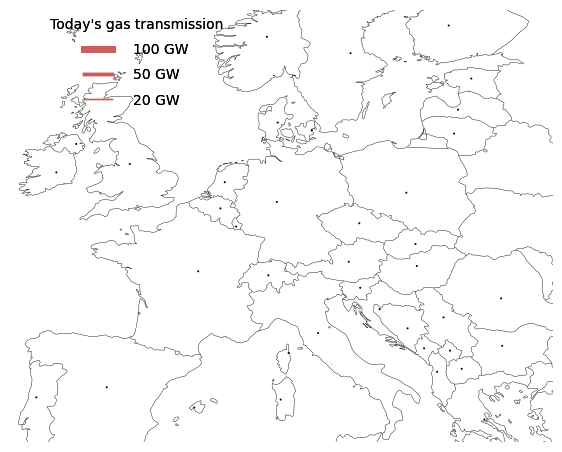

In [11]:
plot_original_gas_network(n)

In [12]:
def plot_original_electricity_network(network):
    n = network.copy()

    lw_factor = 3e3

    n.mremove("Bus", n.buses.index[n.buses.carrier != "AC"])
    n.mremove("Link", n.links.index[~n.links.carrier.str.contains("DC")])

    crs = ccrs.EqualEarth()

    fig, ax = plt.subplots(figsize=(7, 6), subplot_kw={"projection": crs})

    n.plot(
        geomap=True,
        ax=ax,
        bus_sizes=0.005,
        bus_colors="k",
        link_colors=n.links.p_nom.apply(
            lambda x: "darkseagreen" if x > 0 else "skyblue"
        ),
        link_widths=1.5,
        line_widths=n.lines.s_nom / lw_factor,
    )

    handles = []
    labels = []

    for s in (20, 10):
        handles.append(
            plt.Line2D([0], [0], color="rosybrown", linewidth=s * 1e3 / lw_factor)
        )
        labels.append("{} GW HVAC today".format(s))
    l1_1 = ax.legend(
        handles,
        labels,
        loc="upper left",
        bbox_to_anchor=(0.025, 1.01),
        frameon=False,
        labelspacing=0.8,
        handletextpad=1.5,
        # title='Today\'s AC transmission'
    )
    ax.add_artist(l1_1)

    handles = [
        Line2D([0], [0], color="darkseagreen", lw=1.5),
        Line2D([0], [0], color="skyblue", lw=1.5),
    ]
    l2 = ax.legend(
        handles,
        ["HVDC existing", "HVDC planned"],
        frameon=False,
        loc=[0.04, 0.78],
        labelspacing=0.8,
        handletextpad=1.5,
    )

    ax.add_artist(l2)

    fig.savefig(f"{OUTPUT}/electricity-network-today-map.pdf", bbox_inches="tight")

/tmp/ipykernel_64904/1754746507.py:6: DeprecatedWarning: mremove is deprecated as of 0.31 and will be removed in 1.0. Use `n.remove` as a drop-in replacement instead.
  n.mremove("Bus", n.buses.index[n.buses.carrier != "AC"])
/tmp/ipykernel_64904/1754746507.py:7: DeprecatedWarning: mremove is deprecated as of 0.31 and will be removed in 1.0. Use `n.remove` as a drop-in replacement instead.
  n.mremove("Link", n.links.index[~n.links.carrier.str.contains("DC")])
/home/alex-charly/anaconda3/envs/pypsa-eur/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


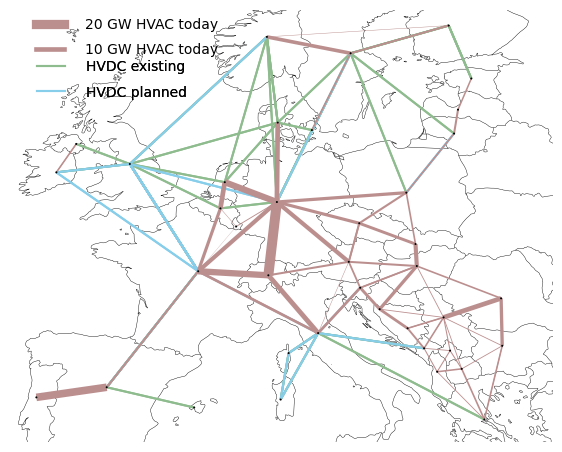

In [13]:
plot_original_electricity_network(n)

## Stats: Per-Country Potentials

In [14]:
def country_potentials(n):
    return (
        n.generators.p_nom_max.groupby([n.generators.carrier, n.generators.bus.str[:2]])
        .sum()
        .div(1e3)
        .unstack(0)
        .round(1)
        .replace([np.inf, -np.inf], np.nan)
        .dropna(axis=1, how="all")
        .fillna(0.0)
    )

In [15]:
p = country_potentials(n)
p

carrier,offwind-ac,offwind-dc,offwind-float,onwind,solar,solar rooftop,solar-hsat
bus,,,,,,,
AL,3.2,0.0,8.9,67.6,53.4,5.1,46.4
AT,0.0,0.0,0.0,139.4,175.9,17.3,152.8
BA,0.0,0.0,0.0,138.6,87.5,6.6,76.0
BE,1.0,1.2,0.0,14.9,104.1,22.3,90.4
BG,1.6,0.0,5.0,145.3,235.3,14.7,204.4
CH,0.0,0.0,0.0,76.6,125.1,15.6,108.6
CZ,0.0,0.0,0.0,103.4,209.4,20.9,181.8
DE,3.9,21.7,0.5,484.2,1078.5,159.7,936.8
DK,17.7,34.2,9.2,57.4,112.6,6.3,97.8


In [16]:
p.to_csv(f"../results/country_potentials.csv")

## Maps: regional demands

In [17]:
def get_oil_demand(with_methanol=False):
    fn = f"{PATH}/pypsa-eur/resources/{RUN}/industrial_energy_demand_base_s_{CLUSTERS}_2050.csv"
    industrial_demand = pd.read_csv(fn, index_col=0)

    fn = f"{PATH}/pypsa-eur/resources/{RUN}/pop_layout_base_s_{CLUSTERS}.csv"
    pop_layout = pd.read_csv(fn, index_col=0)

    fn = f"{PATH}/pypsa-eur/resources/{RUN}/pop_weighted_energy_totals_s_{CLUSTERS}.csv"
    nodal_energy_totals = pd.read_csv(fn, index_col=0)

    oil = [
        "total international aviation",
        "total domestic aviation",
        "total agriculture machinery",
    ]
    if with_methanol:
        oil.append("total domestic navigation")

    demand = industrial_demand["naphtha"] + nodal_energy_totals[oil].sum(axis=1)

    if with_methanol:
        fn = f"{PATH}/pypsa-eur/resources/{RUN}/shipping_demand_s_{CLUSTERS}.csv"
        efficiency = (
            config["sector"]["shipping_oil_efficiency"]
            / config["sector"]["shipping_methanol_efficiency"]
        )
        demand += pd.read_csv(fn, index_col=0).squeeze() * efficiency

    return demand

In [18]:
def get_process_emission():
    fn = f"{PATH}/pypsa-eur/resources/{RUN}/industrial_energy_demand_base_s_{CLUSTERS}_2050.csv"
    industrial_demand = pd.read_csv(fn, index_col=0)

    return industrial_demand["process emission"]

In [19]:
def get_biomass_demand():
    fn = f"{PATH}/pypsa-eur/resources/{RUN}/industrial_energy_demand_base_s_{CLUSTERS}_2050.csv"
    industrial_demand = pd.read_csv(fn, index_col=0)

    return industrial_demand["solid biomass"]

In [20]:
title = {
    "electricity": "Electricity Demand [TWh/a]",
    "H2": "Hydrogen Demand [TWh/a]",
    "heat": "Heat Demand [TWh/a]",
    "solid biomass": "Solid Biomass Demand [TWh/a]",
    "gas": "Methane Demand [TWh/a]",
    "oil": "Liquid Hydrocarbons Demand [TWh/a]",
    "process emission": "Process Emissions [MtCO2/a]",
}

cmap = {
    "electricity": "Blues",
    "H2": "RdPu",
    "heat": "Reds",
    "solid biomass": "Greens",
    "gas": "Oranges",
    "oil": "Greys",
    "process emission": "Greys",
}

regex = {
    "electricity": r"(electricity|EV)",
    "H2": r"(H2|fuel cell)",
    "heat": r"heat",
    "solid biomass": r"biomass",
    "oil": r"( oil|naphtha|kerosene|methanol)",
    "gas": r"gas",
}

In [21]:
demand = as_dense(n, "Load", "p_set").div(1e6)  # TWh
demand_grouped = demand.groupby(
    [n.loads.carrier, n.loads.bus.map(n.buses.location)], axis=1
).sum()
demand_by_region = (n.snapshot_weightings.generators @ demand_grouped).unstack(level=0)

/tmp/ipykernel_64904/3768837307.py:2: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  demand_grouped = demand.groupby(


In [22]:
def plot_regional_demands(df, geodf, carrier, series=None, vmax=None, vmin=0):
    if series is None:
        series = df.filter(regex=regex[carrier]).sum(axis=1).drop("EU")

    proj = ccrs.EqualEarth()
    geodf = geodf.to_crs(proj.proj4_init)

    fig, ax = plt.subplots(figsize=(7, 7), subplot_kw={"projection": proj})

    geodf.plot(
        ax=ax,
        column=series,
        # transform=ccrs.PlateCarree(),
        cmap=cmap[carrier],
        linewidths=0,
        legend=True,
        vmin=vmin,
        vmax=vmax,
        legend_kwds={"label": title[carrier], "shrink": 0.7, "extend": "max"},
    )

    ax.add_feature(cartopy.feature.COASTLINE.with_scale("50m"), linewidth=0.2, zorder=2)
    ax.add_feature(cartopy.feature.BORDERS.with_scale("50m"), linewidth=0.2, zorder=2)

    ax.set_frame_on(False)
    ax.set_facecolor("white")

    plt.savefig(f"{OUTPUT}/demand-map-{carrier}.pdf", bbox_inches="tight")

In [23]:
report = {}
report["demand"] = pd.concat(
    {
        c: demand_by_region.filter(regex=regex[c]).sum(axis=1).drop("EU")
        for c in ["electricity", "H2", "heat"]
    }
    | {"oil": get_oil_demand(with_methanol=True)}
    | {"biomass": get_biomass_demand()}
    | {"process emission": get_process_emission()},
    axis=1,
)

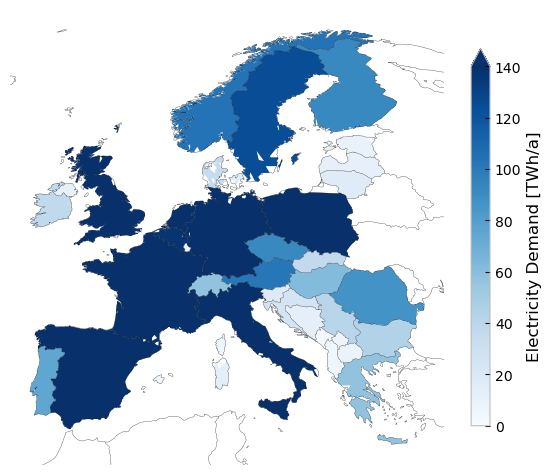

In [24]:
plot_regional_demands(demand_by_region, nodes, "electricity", vmax=140)

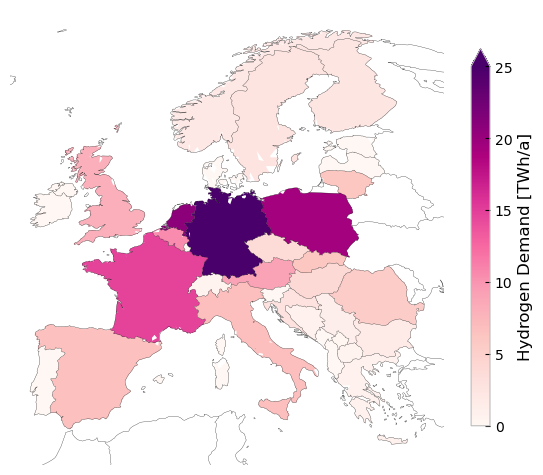

In [25]:
plot_regional_demands(demand_by_region, nodes, "H2", vmax=25)

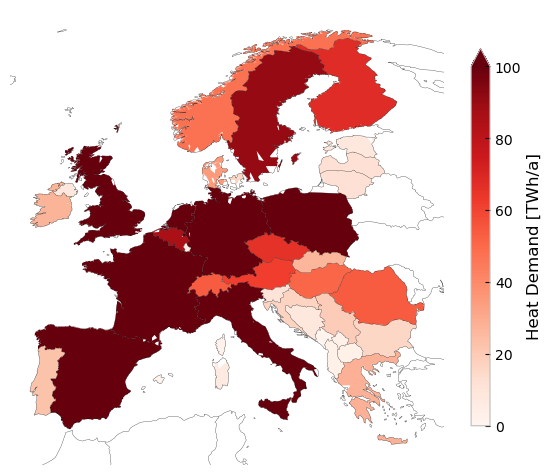

In [26]:
plot_regional_demands(demand_by_region, nodes, "heat", vmax=100)

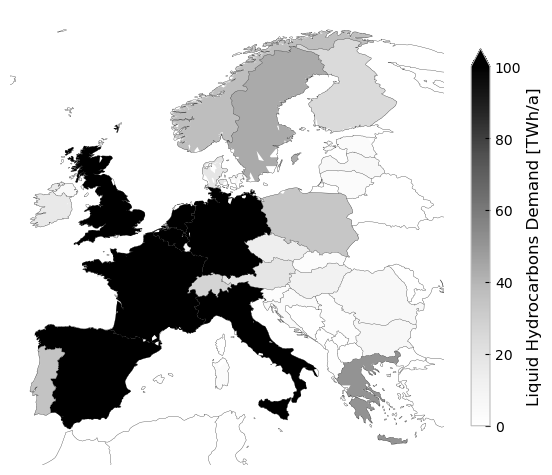

In [27]:
plot_regional_demands(
    demand_by_region, nodes, "oil", series=get_oil_demand(with_methanol=True), vmax=100
)

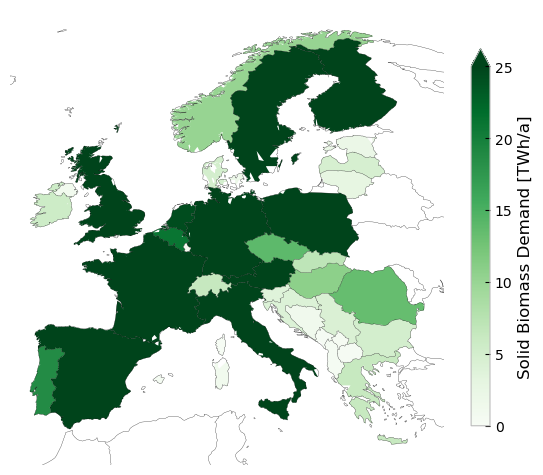

In [28]:
plot_regional_demands(
    demand_by_region, nodes, "solid biomass", series=get_biomass_demand(), vmax=25
)

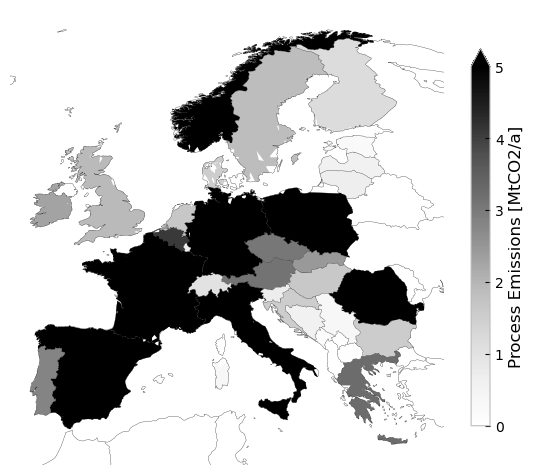

In [29]:
plot_regional_demands(
    demand_by_region, nodes, "process emission", series=get_process_emission(), vmax=5
)

In [30]:
if GAS_NETWORK:
    plot_regional_demands(demand_by_region, nodes, "gas", vmax=16)

## Maps: system-level demands

In [31]:
def plot_system_demands(df, shape, carrier):
    shape["value"] = df.filter(regex=regex[carrier]).sum(axis=1).loc["EU"]

    proj = ccrs.EqualEarth()
    shape = shape.to_crs(proj.proj4_init)

    fig, ax = plt.subplots(figsize=(7, 7), subplot_kw={"projection": proj})

    shape.plot(
        ax=ax,
        column=shape.value,
        # transform=ccrs.PlateCarree(),
        cmap=cmap[carrier],
        linewidths=0,
        vmin=0,
        vmax=shape.value.max() * 2,
        legend=True,
        legend_kwds={
            "label": title[carrier],
            "shrink": 0.7,
        },
    )

    ax.add_feature(cartopy.feature.COASTLINE.with_scale("50m"), linewidth=0.2, zorder=2)

    ax.set_frame_on(False)
    ax.set_facecolor("white")

    plt.savefig(f"{OUTPUT}/demand-map-{carrier}.pdf", bbox_inches="tight")

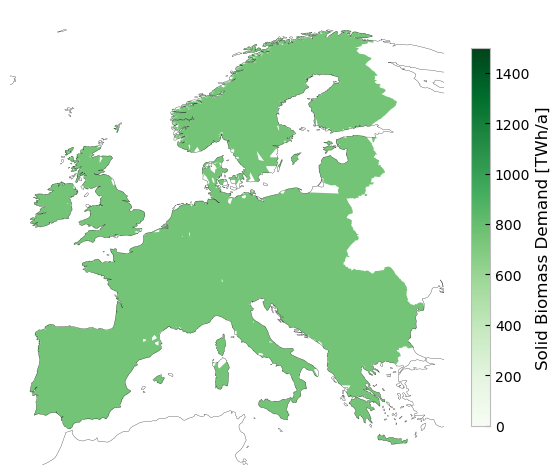

In [32]:
plot_system_demands(demand_by_region, europe_shape, "solid biomass")

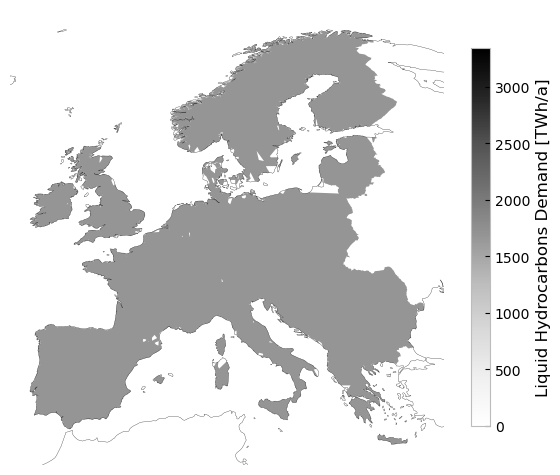

In [33]:
plot_system_demands(demand_by_region, europe_shape, "oil")

## Capacity Factors Renewables

In [34]:
df = (
    n.generators_t.p_max_pu.mean()
    .groupby([n.generators.carrier, n.generators.bus.map(n.buses.location)])
    .first()
    .unstack(0)
    .mul(100)
)

In [35]:
cop = (
    n.links_t.efficiency.mean()
    .groupby([n.links.carrier, n.links.bus0.map(n.buses.location)])
    .first()
    .unstack(0)
)

In [36]:
report["capacity_factor"] = df.groupby(rename_techs_tyndp, axis=1).mean()
report["cop"] = cop.groupby(rename_techs_tyndp, axis=1).mean()

df["ground-sourced heat pump"] = cop.filter(like="ground").mean(axis=1)
df["air-sourced heat pump"] = cop.filter(like="air").mean(axis=1)

/tmp/ipykernel_64904/3880597317.py:1: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  report["capacity_factor"] = df.groupby(rename_techs_tyndp, axis=1).mean()
/tmp/ipykernel_64904/3880597317.py:2: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  report["cop"] = cop.groupby(rename_techs_tyndp, axis=1).mean()


In [37]:
def plot_capacity_factors(
    df,
    geodf,
    carrier,
    cmap="Blues",
    vmax=100,
    vmin=0,
    label="capacity factors [%]",
    fn=None,
):
    proj = ccrs.EqualEarth()
    geodf = geodf.to_crs(proj.proj4_init)

    fig, ax = plt.subplots(figsize=(7, 7), subplot_kw={"projection": proj})

    geodf.plot(
        ax=ax,
        column=df[carrier].reindex(geodf.index),
        cmap=cmap,
        linewidths=0,
        legend=True,
        vmax=vmax,
        vmin=vmin,
        legend_kwds={
            "label": label,
            "shrink": 0.7,
            # "extend": "max",
        },
    )

    ax.add_feature(cartopy.feature.COASTLINE.with_scale("50m"), linewidth=0.2, zorder=2)
    ax.add_feature(cartopy.feature.BORDERS.with_scale("50m"), linewidth=0.2, zorder=2)

    ax.set_frame_on(False)
    ax.set_facecolor("white")

    if fn is None:
        plt.savefig(f"{OUTPUT}/cf-{carrier}.pdf", bbox_inches="tight")

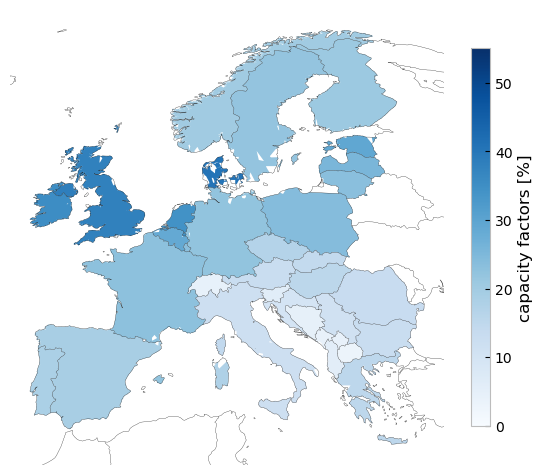

In [38]:
plot_capacity_factors(df, nodes, "onwind", vmax=55)

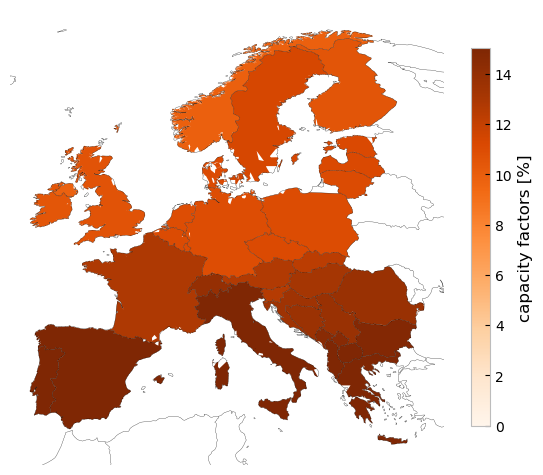

In [39]:
plot_capacity_factors(df, nodes, "solar", "Oranges", vmax=15)

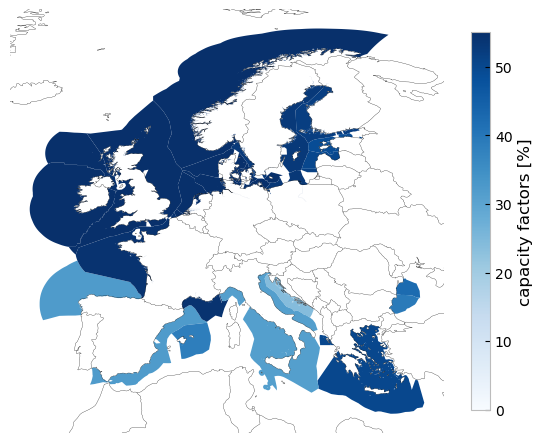

In [40]:
plot_capacity_factors(df, offnodes, "offwind-dc", vmax=55)

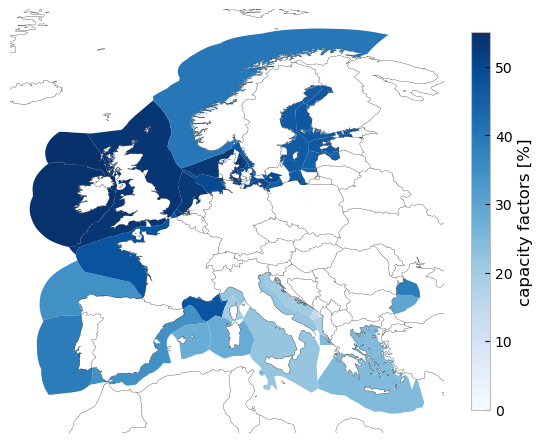

In [41]:
plot_capacity_factors(df, offnodes, "offwind-ac", vmax=55)

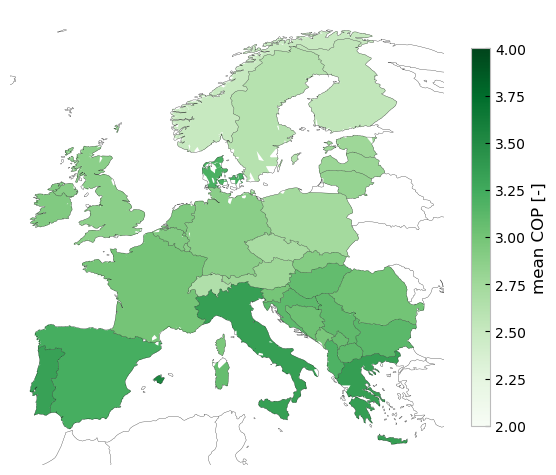

In [42]:
plot_capacity_factors(
    df,
    nodes,
    "air-sourced heat pump",
    cmap="Greens",
    vmax=4,
    vmin=2,
    label="mean COP [-]",
)

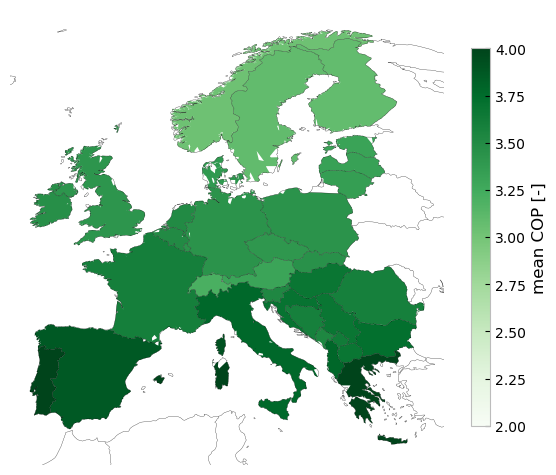

In [43]:
plot_capacity_factors(
    df,
    nodes,
    "ground-sourced heat pump",
    cmap="Greens",
    vmax=4,
    vmin=2,
    label="mean COP [-]",
)

## Demand Totals

In [44]:
mapping = {
    "H2 for industry": "hydrogen",
    "H2 for shipping": "hydrogen",
    "agriculture electricity": "electricity",
    "agriculture heat": "heat",
    "agriculture machinery oil": "oil",
    "agriculture machinery oil emissions": "emissions",
    "electricity": "electricity",
    "gas for industry": "methane",
    "industry electricity": "electricity",
    "kerosene for aviation": "oil",
    "land transport EV": "electricity",
    "land transport fuel cell": "hydrogen",
    "low-temperature heat for industry": "heat",
    "naphtha for industry": "oil",
    "industry methanol": "methanol", #H2G-A: Double check
    "shipping methanol": "methanol",
    "shipping methanol emissions": "emissions",
    "oil emissions": "emissions",
    "process emissions": "emissions",
    "residential rural heat": "heat",
    "residential urban decentral heat": "heat",
    "services rural heat": "heat",
    "services urban decentral heat": "heat",
    "solid biomass for industry": "solid biomass",
    "urban central heat": "heat", 
    "rural heat": "heat", #H2G-A: Double check
    "urban decentral heat": "heat", #H2G-A: Double check
}

In [45]:
mapping_sector = {
    "H2 for industry": ("hydrogen", "industry"),
    "H2 for shipping": ("hydrogen", "shipping"),
    "agriculture electricity": ("electricity", "agriculture"),
    "agriculture heat": ("heat", "agriculture"),
    "agriculture machinery oil": ("oil", "agriculture"),
    "agriculture machinery oil emissions": ("emissions", "agriculture"),
    "electricity": ("electricity", "residential"),
    "gas for industry": ("methane", "industry"),
    "industry electricity": ("electricity", "industry"),
    "kerosene for aviation": ("oil", "aviation"),
    "land transport EV": ("electricity", "land transport"),
    "land transport fuel cell": ("hydrogen", "land transport"),
    "low-temperature heat for industry": ("heat", "industry"),
    "naphtha for industry": ("oil", "industry"),
    "industry methanol": ("methanol", "industry"),
    "shipping methanol": ("methanol", "shipping"),
    "shipping methanol emissions": ("emissions", "other"),
    "oil emissions": ("emissions", "other"),
    "process emissions": ("emissions", "process"),
    "residential rural heat": ("heat", "residential rural"),
    "residential urban decentral heat": ("heat", "residential urban"),
    "services rural heat": ("heat", "services rural"),
    "services urban decentral heat": ("heat", "services urban"),
    "solid biomass for industry": ("solid biomass", "industry"),
    "urban central heat": ("heat", "district heating"),
    "rural heat": ("heat-rural", "district heating"), #H2G-A: Double check
    "urban decentral heat": ("heat-decentral", "district heating"), #H2G-A: Double check
}

In [46]:
order = [
    "electricity",
    "heat",
    "oil",
    "methanol",
    "solid biomass",
    "methane",
    "hydrogen",
]

In [47]:
df = demand_by_region.sum()

In [48]:
mapping

{'H2 for industry': 'hydrogen',
 'H2 for shipping': 'hydrogen',
 'agriculture electricity': 'electricity',
 'agriculture heat': 'heat',
 'agriculture machinery oil': 'oil',
 'agriculture machinery oil emissions': 'emissions',
 'electricity': 'electricity',
 'gas for industry': 'methane',
 'industry electricity': 'electricity',
 'kerosene for aviation': 'oil',
 'land transport EV': 'electricity',
 'land transport fuel cell': 'hydrogen',
 'low-temperature heat for industry': 'heat',
 'naphtha for industry': 'oil',
 'industry methanol': 'methanol',
 'shipping methanol': 'methanol',
 'shipping methanol emissions': 'emissions',
 'oil emissions': 'emissions',
 'process emissions': 'emissions',
 'residential rural heat': 'heat',
 'residential urban decentral heat': 'heat',
 'services rural heat': 'heat',
 'services urban decentral heat': 'heat',
 'solid biomass for industry': 'solid biomass',
 'urban central heat': 'heat',
 'rural heat': 'heat',
 'urban decentral heat': 'heat'}

In [49]:
df.index = pd.MultiIndex.from_tuples([(mapping[i], i) for i in df.index])

In [50]:
df.drop("emissions", inplace=True)

/tmp/ipykernel_64904/2335913672.py:1: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  df.drop("emissions", inplace=True)


In [51]:
colors = config["plotting"]["tech_colors"]
colors["solid biomass"] = "seagreen"
colors["methane"] = "#db6a25"

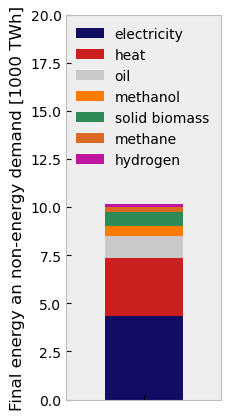

In [52]:
pd.DataFrame(df.groupby(level=0).sum().div(1e3).loc[order], columns=[""]).T.plot.bar(
    stacked=True,
    color=colors,
    figsize=(2, 5),
    ylim=[0, 20],
    ylabel="Final energy an non-energy demand [1000 TWh]",
)
plt.savefig(f"{OUTPUT}/total-annual-demand.pdf", bbox_inches="tight")

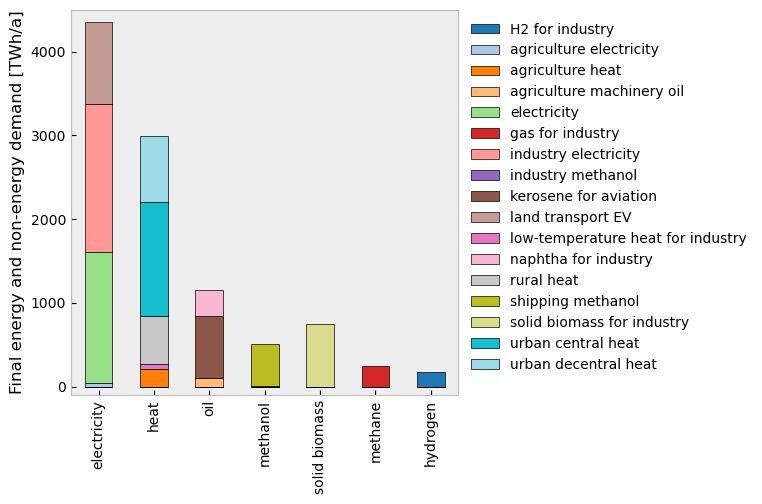

In [53]:
fig, ax = plt.subplots(figsize=(5, 5))

df.unstack().loc[order].plot.bar(
    ax=ax, stacked=True, cmap="tab20", edgecolor="k", ylim=(-100, 4500)
)

plt.legend(bbox_to_anchor=(1, 1))

plt.ylabel("Final energy and non-energy demand [TWh/a]")

plt.savefig(f"{OUTPUT}/demand-by-carrier.pdf")

In [54]:
df = demand_by_region.sum()

In [55]:
df.index = pd.MultiIndex.from_tuples([mapping_sector[i] for i in df.index])

In [56]:
df = df.loc[df > 0]

In [57]:
df

hydrogen        industry             177.870000
electricity     agriculture           37.525884
heat            agriculture          214.811743
oil             agriculture          102.847639
electricity     residential         1574.975244
methane         industry             240.400000
electricity     industry            1757.120000
methanol        industry               8.740000
oil             aviation             743.906977
electricity     land transport       980.580983
heat            industry              59.980000
oil             industry             311.530000
heat-rural      district heating     566.724006
methanol        shipping             502.969705
solid biomass   industry             748.250000
heat            district heating    1360.088729
heat-decentral  district heating     788.457234
dtype: float64

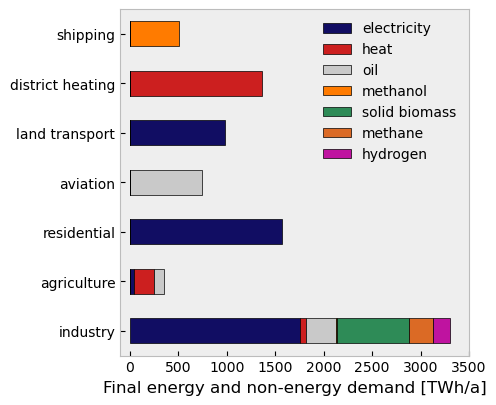

In [58]:
fig, ax = plt.subplots(figsize=(4.5, 4.5))

df.unstack().loc[order].T.plot.barh(
    ax=ax, color=colors, stacked=True, edgecolor="k", xlim=(-100, 3500)
)

plt.legend(bbox_to_anchor=(1, 1))

plt.xlabel("Final energy and non-energy demand [TWh/a]")

plt.savefig(f"{OUTPUT}/demand-by-sector-carrier.pdf")

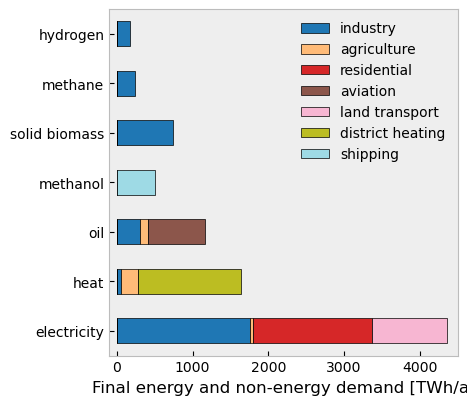

In [59]:
fig, ax = plt.subplots(figsize=(4.5, 4.5))

df.unstack().loc[order].plot.barh(
    ax=ax, stacked=True, cmap="tab20", edgecolor="k", xlim=(-100, 4500)
)

plt.legend(bbox_to_anchor=(1, 1))

plt.xlabel("Final energy and non-energy demand [TWh/a]")

plt.savefig(f"{OUTPUT}/demand-by-carrier-sector.pdf")

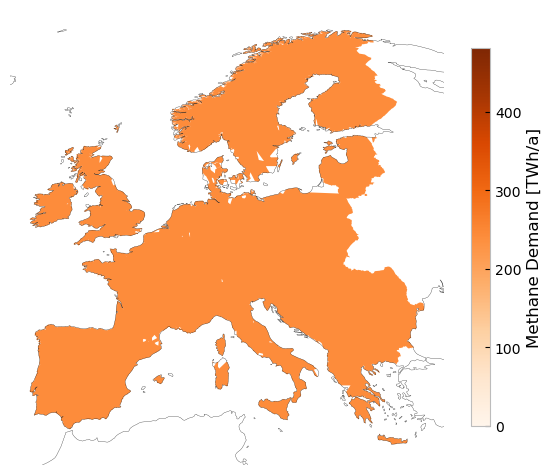

In [60]:
if not GAS_NETWORK:
    plot_system_demands(demand_by_region, europe_shape, "gas")

## Demand Time Series

In [61]:
kwargs = dict(ylim=[0, 1], xlabel="", figsize=(8, 2))

In [62]:
trans = n.loads_t.p_set.filter(like="land transport EV").sum(axis=1)
trans /= trans.max()

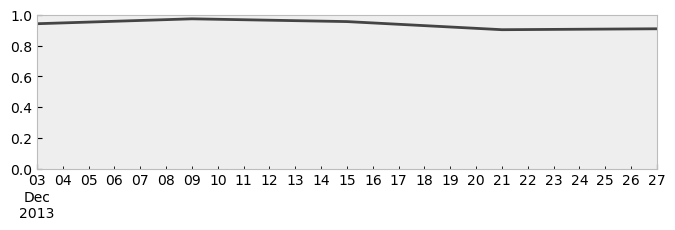

In [63]:
trans["12-2013"].plot(**kwargs, c="#444444")
plt.savefig(f"{OUTPUT}/bev-demand-month.pdf", bbox_inches="tight")

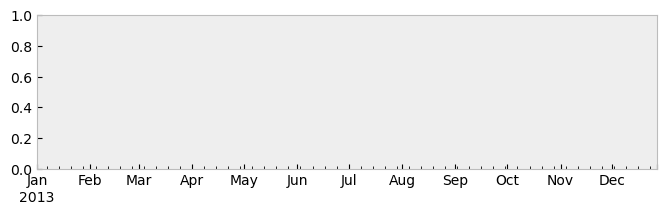

In [64]:
trans.resample("D").mean().plot(**kwargs, c="#444444")
plt.savefig(f"{OUTPUT}/bev-demand-year.pdf", bbox_inches="tight")

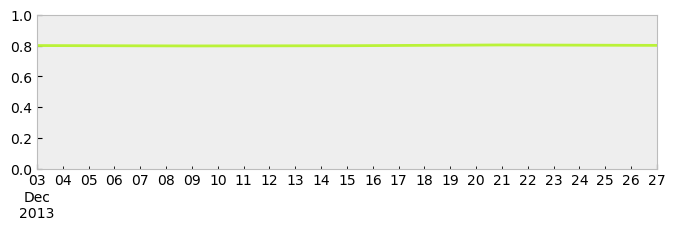

In [65]:
avail = n.links_t.p_max_pu.mean(axis=1)
avail["12-2013"].plot(**kwargs, c="#baf238")
plt.savefig(f"{OUTPUT}/bev-availability-month.pdf", bbox_inches="tight")

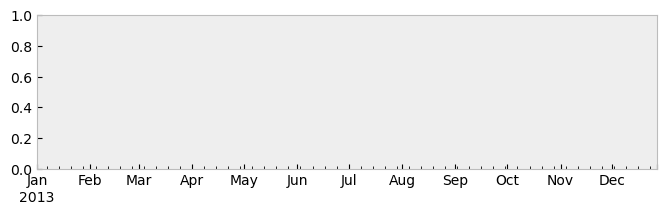

In [66]:
avail.resample("D").mean().plot(**kwargs, c="#baf238")
plt.savefig(f"{OUTPUT}/bev-availability-year.pdf", bbox_inches="tight")

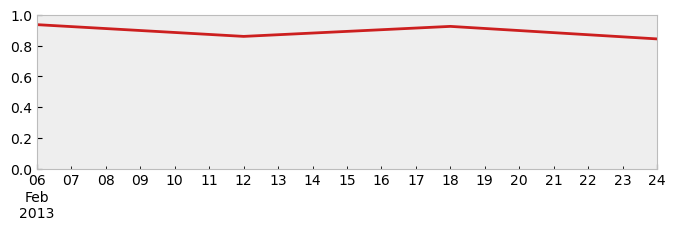

In [67]:
heat = n.loads_t.p_set.filter(like="heat").sum(axis=1)
heat /= heat.max()
heat["02-2013"].plot(**kwargs, c="#cc1f1f")
plt.savefig(f"{OUTPUT}/heat-demand-month.pdf", bbox_inches="tight")

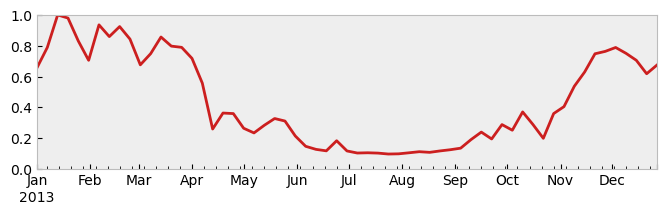

In [68]:
heat.plot(**kwargs, c="#cc1f1f")
plt.savefig(f"{OUTPUT}/heat-demand-year.pdf", bbox_inches="tight")

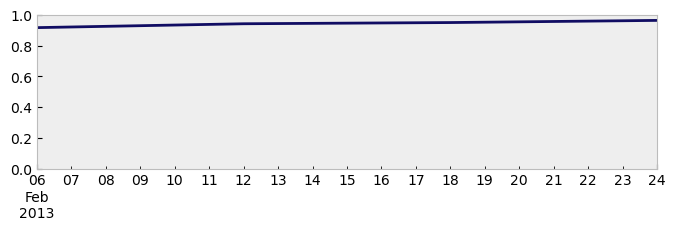

In [69]:
elec = n.loads_t.p_set.loc[
    :, n.loads.bus.map(n.buses.carrier).isin(["AC", "low voltage"])
].sum(axis=1)
elec /= elec.max()
elec["02-2013"].plot(**kwargs, c="#110d63")
plt.savefig(f"{OUTPUT}/elec-demand-month.pdf", bbox_inches="tight")

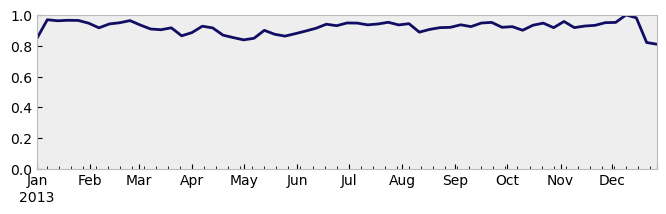

In [70]:
elec.plot(**kwargs, c="#110d63")
plt.savefig(f"{OUTPUT}/elec-demand-year.pdf", bbox_inches="tight")

In [71]:
loads = as_dense(n, "Load", "p_set")

In [72]:
heat = loads.filter(like="heat").sum(axis=1).div(1e3)

In [73]:
elec_nodes = n.loads.bus.map(n.buses.carrier).isin(
    ["AC", "low voltage", "Li ion", "battery"]
)

In [74]:
elec = loads.loc[:, elec_nodes].sum(axis=1).div(1e3)  # GW

In [75]:
gas_nodes = n.loads.bus.map(n.buses.carrier).isin(["gas", "biogas", "gas for industry"])
gas = loads.loc[:, gas_nodes].sum(axis=1).div(1e3)  # GW

In [76]:
h2_nodes = n.loads.bus.map(n.buses.carrier).isin(["H2", "H2 liquid"])
h2 = loads.loc[:, h2_nodes].sum(axis=1).div(1e3)  # GW

In [77]:
bio_nodes = n.loads.bus.map(n.buses.carrier).isin(
    ["solid biomass", "solid biomass for industry"]
)
bio = loads.loc[:, bio_nodes].sum(axis=1).div(1e3)  # GW

In [78]:
oil_nodes = n.loads.bus.map(n.buses.carrier).isin(["oil", "methanol"])
oil = loads.loc[:, oil_nodes].sum(axis=1).div(1e3)  # GW

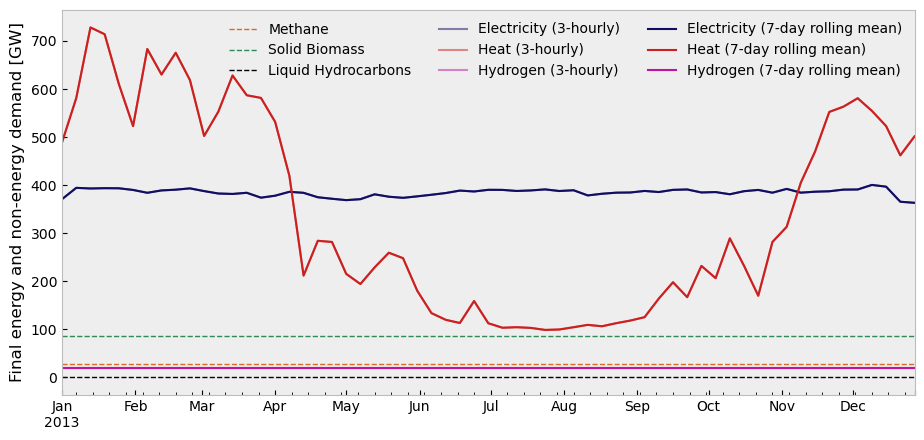

In [79]:
fig, ax = plt.subplots(figsize=(11, 5))

gas.plot(ax=ax, color="#db6a25", label="Methane", linestyle="--", linewidth=1)
bio.plot(ax=ax, color="seagreen", label="Solid Biomass", linestyle="--", linewidth=1)
oil.plot(ax=ax, color="k", label="Liquid Hydrocarbons", linestyle="--", linewidth=1)

elec.plot(
    ax=ax, color="#110d63", alpha=0.5, label="Electricity (3-hourly)", linewidth=1.5
)
heat.plot(ax=ax, color="#cc1f1f", alpha=0.5, label="Heat (3-hourly)", linewidth=1.5)
h2.plot(ax=ax, color="#bf13a0", alpha=0.5, label="Hydrogen (3-hourly)", linewidth=1.5)


elec.rolling(window="7D", center=True).mean().plot(
    ax=ax, color="#110d63", label="Electricity (7-day rolling mean)", linewidth=1.5
)
heat.rolling(window="7D", center=True).mean().plot(
    ax=ax, color="#cc1f1f", label="Heat (7-day rolling mean)", linewidth=1.5
)
h2.rolling(window="7D", center=True).mean().plot(
    ax=ax, color="#bf13a0", label="Hydrogen (7-day rolling mean)", linewidth=1.5
)

plt.xlabel("")
plt.legend(ncol=3)
plt.ylabel("Final energy and non-energy demand [GW]")

plt.savefig(f"{OUTPUT}/ts-demand.pdf", bbox_inches="tight")

## CO2

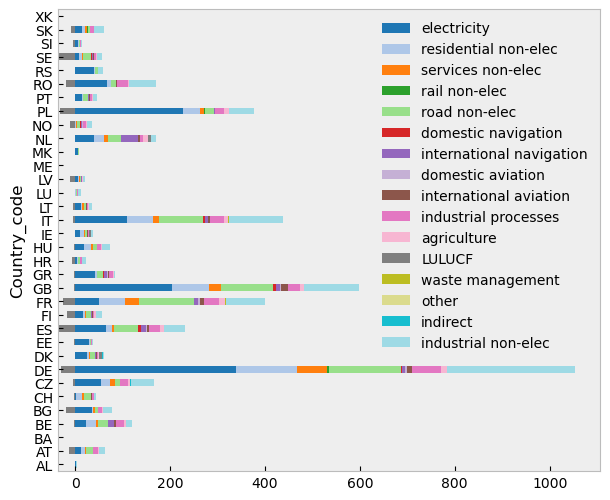

In [80]:
co2 = pd.read_csv(PATH + f"pypsa-eur/resources/{RUN}/co2_totals.csv", index_col=0) #H2G-A: Changed

fig, ax = plt.subplots(figsize=(7, 6))
co2.plot.barh(ax=ax, stacked=True, cmap="tab20")
plt.savefig(OUTPUT + "/co2.pdf")

## Industrial Production Fuel Switching

In [81]:
fn = PATH + f"pypsa-eur/resources/{RUN}/industrial_production_per_country.csv"
iproduction_today = pd.read_csv(fn, index_col=0).sum()

fn = (
    PATH + f"pypsa-eur/resources/{RUN}/industrial_production_per_country_tomorrow_2050.csv"
)
iproduction_tomorrow = pd.read_csv(fn, index_col=0).sum()

fn = PATH + f"pypsa-eur/resources/{RUN}/industry_sector_ratios.csv"
iratios = pd.read_csv(fn, index_col=0)

fn = PATH + f"pypsa-eur/resources/{RUN}/industrial_energy_demand_per_country_today.csv"
ienergy_today = (
    pd.read_csv(
        fn,
        index_col=0,
        header=[0, 1],
    )
    .groupby(level=1, axis=1)
    .sum()
)

/tmp/ipykernel_64904/3172162165.py:19: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  .groupby(level=1, axis=1)


In [82]:
ienergy_today.rename({"gas": "methane"}, inplace=True)

In [83]:
iratios.rename({"elec": "electricity", "naphtha": "liquid"}, inplace=True)
iratios.loc["solid", :] = iratios.loc[["coke", "coal"]].sum()
iratios.drop(
    ["coke", "coal", "process emission", "process emission from feedstock"],
    axis=0,
    inplace=True,
)

In [84]:
ienergy_tomorrow = iratios * iproduction_tomorrow / 1e3
bc = [
    "Chlorine",
    "HVC",
    "HVC (mechanical recycling)",
    "HVC (chemical recycling)",
    "Methanol",
]

In [85]:
ienergy_tomorrow["Basic chemicals (without ammonia)"] = ienergy_tomorrow[bc].sum(axis=1)
ienergy_tomorrow.drop(bc, axis=1, inplace=True)
ienergy_today["DRI + Electric arc"] = 0.0
ienergy_today.loc["hydrogen", :] = 0.0
ienergy_tomorrow.loc["other", :] = 0.0
ienergy_tomorrow.loc["waste", :] = 0.0

In [86]:
ienergy_tomorrow.sort_index(axis=1, inplace=True)
ienergy_today.sort_index(axis=1, inplace=True)

ienergy_tomorrow.sort_index(axis=0, inplace=True)
ienergy_today.sort_index(axis=0, inplace=True)

In [87]:
tech_colors = config["plotting"]["tech_colors"]

In [88]:
tech_colors["electricity"] = "#ace37f"
tech_colors["hydrogen"] = "#f073da"

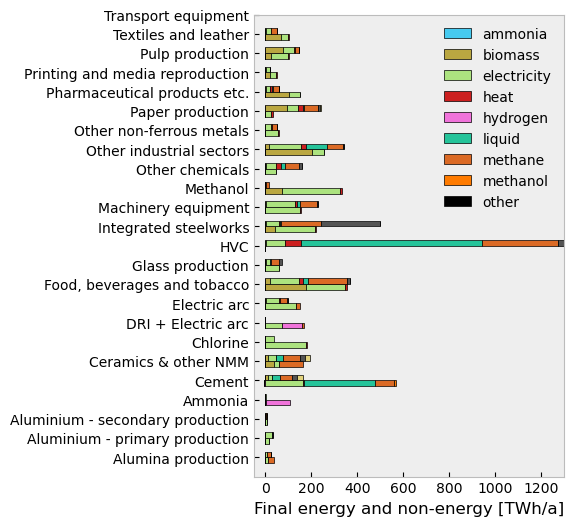

In [89]:
fig, ax = plt.subplots(figsize=(4, 6))

ienergy_tomorrow.T.plot.barh(
    ax=ax, stacked=True, width=0.3, color=tech_colors, position=1, edgecolor="k"
)
ienergy_today.T.plot.barh(
    ax=ax, stacked=True, width=0.3, color=tech_colors, position=0, edgecolor="k"
)


plt.xlabel("Final energy and non-energy [TWh/a]")
plt.xlim(-50, 1300)
plt.ylim(-1, 23)
handles, labels = ax.get_legend_handles_labels()
n = ienergy_today.shape[0]
plt.legend(handles[:n], labels[:n])
plt.savefig(OUTPUT + "/fec_industry_today_tomorrow.pdf", bbox_inches="tight")

In [90]:
df = ienergy_tomorrow.sum(axis=1).sort_values(ascending=False)
df = df.loc[df > 0]

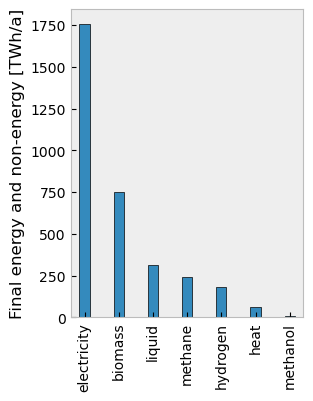

In [91]:
fig, ax = plt.subplots(figsize=(3, 4))

df.plot.bar(ax=ax, width=0.3, edgecolor="k")

plt.ylabel("Final energy and non-energy [TWh/a]")
plt.xlabel("")

plt.savefig(OUTPUT + "/fec_industry_tomorrow_by_carrier.pdf", bbox_inches="tight")

## Process Emissions

In [92]:
pe = (
    pd.read_csv(
        PATH + f"pypsa-eur/resources/{RUN}/industry_sector_ratios.csv", index_col=0
    )
    .filter(like="process emission", axis=0)
    .sum()
)

In [93]:
pe_today = iproduction_today * pe / 1e3

In [94]:
pe_tomorrow = iproduction_tomorrow * pe / 1e3

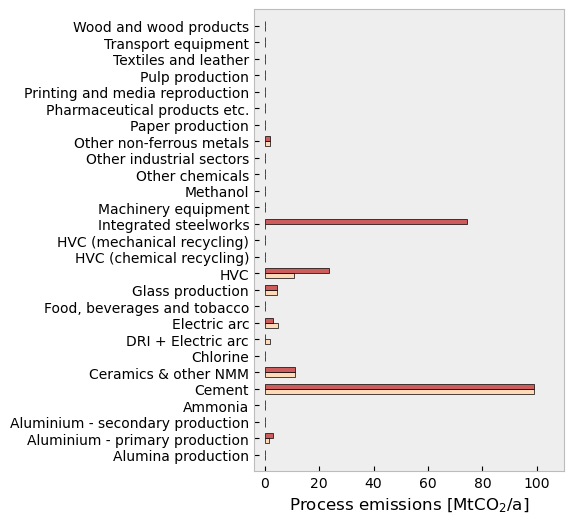

In [95]:
fig, ax = plt.subplots(figsize=(4, 6))

pe_tomorrow.plot.barh(ax=ax, width=0.3, color="peachpuff", position=1, edgecolor="k")
pe_today.plot.barh(ax=ax, width=0.3, color="indianred", position=0, edgecolor="k")

plt.xlabel(f"Process emissions [MtCO$_2$/a]")
plt.xlim(-4, 110)
plt.ylim(-1, 27)
handles, labels = ax.get_legend_handles_labels()
plt.legend(
    handles[:n],
    [
        f"2050:  {pe_tomorrow.sum():.0f} MtCO$_2$/a",
        f"today: {pe_today.sum():.0f} MtCO$_2$/a",
    ],
)
plt.savefig(OUTPUT + "/process-emissions.pdf", bbox_inches="tight")

## Power Plants

In [96]:
df = pd.read_csv(PATH + f"pypsa-eur/resources/{RUN}/powerplants_s_{CLUSTERS}.csv", index_col=0)

df = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(df.lon, df.lat), crs="EPSG:4326")

df.Fueltype = df.Fueltype.str.strip().replace("CCGT, Thermal", "CCGT")

df = df.loc[
    ~df.Fueltype.isin(["Other", "Pv", "Storage Technologies", "not found", "Not Found"])
]

colors = {
    "Bioenergy": "#80c944",
    "CCGT": "#a85522",
    "Geothermal": "red",
    "Hard Coal": "black",
    "Lignite": "#826837",
    "Hydro": "#235ebc",
    "Nuclear": "#ff8c00",
    "OCGT": "#e0986c",
    "Oil": "#c9c9c9",
    "Waste": "purple",
}

In [97]:
crs = ccrs.AlbersEqualArea()

df = df.cx[-12:30, 35:72]
df = df.to_crs(crs.proj4_init)

fig, ax = plt.subplots(figsize=(9.5, 9.5), subplot_kw={"projection": crs})

ax.add_feature(cartopy.feature.COASTLINE.with_scale("50m"), linewidth=0.2, zorder=2)
ax.add_feature(cartopy.feature.BORDERS.with_scale("50m"), linewidth=0.2, zorder=2)

df.plot(
    ax=ax,
    column="Fueltype",
    markersize=df["Capacity"] / 35,
    alpha=0.75,
    legend=True,
    cmap=mcolors.ListedColormap(
        pd.Series(df.Fueltype.unique()).sort_values().map(colors).values
    ),
    legend_kwds=dict(title="Technology (size ~ capacity)", frameon=False),
)


ax.set_frame_on(False)
ax.set_facecolor("white")
plt.savefig(OUTPUT + "/powerplants.pdf", bbox_inches="tight")

ValueError: Invalid RGBA argument: nan

Error in callback <function _draw_all_if_interactive at 0x7f3e30fc0b80> (for post_execute), with arguments args (),kwargs {}:


ValueError: Invalid RGBA argument: nan

ValueError: Invalid RGBA argument: nan

<Figure size 950x950 with 1 Axes>

## Hotmaps Industrial Sites

In [ ]:
def prepare_hotmaps_database():
    """
    Load hotmaps database of industrial sites.
    """

    df = pd.read_csv(
        PATH + "pypsa-eur/data/Industrial_Database.csv", sep=";", index_col=0
    )

    df[["srid", "coordinates"]] = df.geom.str.split(";", expand=True)

    # remove those sites without valid locations
    df.drop(df.index[df.coordinates.isna()], inplace=True)

    df["coordinates"] = gpd.GeoSeries.from_wkt(df["coordinates"])

    gdf = gpd.GeoDataFrame(df, geometry="coordinates", crs="EPSG:4326")

    return gdf

In [ ]:
crs = ccrs.AlbersEqualArea()

hotmaps = prepare_hotmaps_database()
hotmaps = hotmaps.cx[-12:30, 35:72]
hotmaps = hotmaps.to_crs(crs.proj4_init)

fig, ax = plt.subplots(figsize=(9.5, 9.5), subplot_kw={"projection": crs})

ax.add_feature(cartopy.feature.COASTLINE.with_scale("50m"), linewidth=0.2, zorder=2)
ax.add_feature(cartopy.feature.BORDERS.with_scale("50m"), linewidth=0.2, zorder=2)

hotmaps.plot(
    ax=ax,
    column="Subsector",
    markersize=hotmaps["Emissions_ETS_2014"] / 3e4,
    alpha=0.5,
    legend=True,
    # transform=ccrs.epsg(3395),
    legend_kwds=dict(title="Industry Sector (size ~ emissions)", frameon=False),
)


ax.set_frame_on(False)
ax.set_facecolor("white")

plt.savefig(OUTPUT + "/hotmaps.pdf", bbox_inches="tight")

## Salt Caverns

In [ ]:
cavern_nodes = pd.read_csv(
    f"{PATH}/pypsa-eur/resources/{RUN}/salt_cavern_potentials_s_{CLUSTERS}.csv",
    index_col=0,
)
cavern_nodes = cavern_nodes.where(cavern_nodes > 0.5)

In [ ]:
report["salt_caverns"] = cavern_nodes

In [ ]:
cavern_regions = gpd.read_file(
    f"{PATH}pypsa-eur/resources/{RUN}/regions_onshore_base_s_{CLUSTERS}.geojson"
).set_index("name")

In [ ]:
cavern_offregions = gpd.read_file(
    f"{PATH}/pypsa-eur/resources/{RUN}/regions_offshore_base_s_{CLUSTERS}.geojson"
).set_index("name")

In [ ]:
cavern_regions.to_crs(crs.proj4_init).total_bounds

In [ ]:
def plot_salt_caverns_by_node(
    cavern_nodes,
    cavern_regions,
    storage_type="onshore",
    cmap="GnBu",
    vmin=1,
    vmax=3000,
    fn=None,
    label=r"H$_2$ Storage Potential [TWh]",
):
    crs = ccrs.EqualEarth()

    cavern_regions = cavern_regions.to_crs(crs.proj4_init)

    fig, ax = plt.subplots(figsize=(7, 7), subplot_kw={"projection": crs})

    cavern_regions.plot(
        ax=ax,
        column=cavern_nodes[storage_type].reindex(cavern_regions.index),
        # transform=ccrs.PlateCarree(),
        cmap=cmap,
        linewidths=0,
        legend=True,
        vmin=vmin,
        vmax=vmax,
        legend_kwds={
            "label": label,
            "shrink": 0.7,
            "extend": "max",
        },
        norm=mcolors.LogNorm(vmin=1, vmax=vmax),
    )

    plt.title(f"{storage_type.capitalize()} Salt Cavern H$_2$ Storage Potentials")

    plt.xlim(-1.2e6, 2.6e6)
    plt.ylim(4.3e6, 7.8e6)

    # plt.xlim(-14.5, 31.5)
    # plt.ylim(34, 72)

    ax.add_feature(cartopy.feature.COASTLINE.with_scale("50m"), linewidth=0.2, zorder=2)
    ax.add_feature(cartopy.feature.BORDERS.with_scale("50m"), linewidth=0.2, zorder=2)

    ax.set_frame_on(False)
    ax.set_facecolor("white")

    if fn is None:
        plt.savefig(
            f"{OUTPUT}/cavern-potentials-{storage_type}.pdf", bbox_inches="tight"
        )

In [ ]:
plot_salt_caverns_by_node(cavern_nodes, cavern_regions, storage_type="onshore")

In [ ]:
plot_salt_caverns_by_node(cavern_nodes, cavern_regions, storage_type="nearshore")

In [ ]:
plot_salt_caverns_by_node(cavern_nodes, cavern_offregions, storage_type="offshore")

In [ ]:
caverns = gpd.read_file(
    f"{PATH}/pypsa-eur/data/bundle/h2_salt_caverns_GWh_per_sqkm.geojson"
)

crs = ccrs.EqualEarth()

caverns = caverns.to_crs(crs.proj4_init)

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw={"projection": crs})

ax.add_feature(cartopy.feature.COASTLINE.with_scale("50m"), linewidth=0.2, zorder=2)
ax.add_feature(cartopy.feature.BORDERS.with_scale("50m"), linewidth=0.2, zorder=2)

caverns.plot(
    ax=ax,
    column="storage_type",
    cmap="tab10_r",  # "tab10_r",
    legend=True,
    linewidth=0,
    # transform=ccrs.epsg(3395),
    legend_kwds=dict(
        title="Salt Caverns for\nHydrogen Storage", frameon=False, loc=(0.2, 0.8)
    ),
)


plt.xlim(-1e6, 2.6e6)
plt.ylim(4.3e6, 7.8e6)

ax.set_frame_on(False)
ax.set_facecolor("white")

plt.savefig(OUTPUT + "/caverns.pdf", bbox_inches="tight")

## Biomass potentials

In [ ]:
fn = PATH + f"pypsa-eur/resources/{RUN}/biomass_potentials_s_{CLUSTERS}_{planning_year}.csv"
bio = pd.read_csv(fn, index_col=0).div(1e6).drop("not included", axis=1)  # TWh/a

In [ ]:
report["biomass_potentials"] = bio

In [ ]:
def plot_biomass_potentials(bio, nodes, kind, fn=None):
    crs = ccrs.EqualEarth()
    nodes = nodes.to_crs(crs.proj4_init)

    fig, ax = plt.subplots(figsize=(7, 7), subplot_kw={"projection": crs})

    ax.add_feature(cartopy.feature.COASTLINE.with_scale("50m"), linewidth=0.2, zorder=2)
    ax.add_feature(cartopy.feature.BORDERS.with_scale("50m"), linewidth=0.2, zorder=2)

    nkind = "disregarded biomass" if kind == "not included" else kind
    label = f"{nkind} potentials [TWh/a]"

    nodes.plot(
        ax=ax,
        column=bio[kind],
        cmap="Greens",  # "tab10_r",
        legend=True,
        linewidth=0,
        legend_kwds={
            "label": label,
            "shrink": 0.7,
            "extend": "max",
        },
    )

    total = bio[kind].sum()

    ax.text(-0.8e6, 7.4e6, f"total: {total:.0f} TWh/a", fontsize=15, color="#343434")

    plt.xlim(-1e6, 2.6e6)
    plt.ylim(4.3e6, 7.8e6)

    ax.set_frame_on(False)
    ax.set_facecolor("white")

    if fn is None:
        plt.savefig(OUTPUT + f"/biomass-{kind}.pdf", bbox_inches="tight")

In [ ]:
for kind in bio.columns:
    plot_biomass_potentials(bio, nodes, kind)

## Ammonia Production

In [ ]:
fn = PATH + f"pypsa-eur/resources/{RUN}/ammonia_production.csv"
df = pd.read_csv(fn, index_col=0)  # kt/a

In [ ]:
def plot_ammonia_production(df, cts, year, fn=None):
    year = str(year)

    crs = ccrs.EqualEarth()
    cts = cts.to_crs(crs.proj4_init)

    fig, ax = plt.subplots(figsize=(7, 7), subplot_kw={"projection": crs})

    ax.add_feature(cartopy.feature.COASTLINE.with_scale("50m"), linewidth=0.2, zorder=2)
    ax.add_feature(cartopy.feature.BORDERS.with_scale("50m"), linewidth=0.2, zorder=2)

    cts.plot(
        ax=ax,
        column=df[year].reindex(cts.index),
        cmap="Purples",  # "tab10_r",
        legend=True,
        linewidth=0,
        legend_kwds={
            "label": "Ammonia Production [kt]",
            "shrink": 0.7,
        },
    )

    total = df[year].sum()
    ax.text(
        -0.85e6, 7.4e6, f"total: {total:.0f} kt ({year})", fontsize=12, color="#343434"
    )

    plt.xlim(-1e6, 2.6e6)
    plt.ylim(4.3e6, 7.8e6)

    ax.set_frame_on(False)

    if fn is None:
        plt.savefig(OUTPUT + f"/ammonia-{year}.pdf", bbox_inches="tight")

In [ ]:
plot_ammonia_production(df, cts, 2022)

## Gas Network Unclustered

In [ ]:
lng_fn = PATH + "pypsa-eur/data/gas_network/scigrid-gas/data/IGGIELGN_LNGs.geojson"
entry_fn = (
    PATH
    + "pypsa-eur/data/gas_network/scigrid-gas/data/IGGIELGN_BorderPoints.geojson"
)
prod_fn = (
    PATH
    + "pypsa-eur/data/gas_network/scigrid-gas/data/IGGIELGN_Productions.geojson"
)
planned_lng_fn = PATH + "pypsa-eur/data/gas_network/planned_LNGs.csv"

regions_onshore = PATH + "pypsa-eur/resources/regions_onshore_elec_s_181.geojson"
regions_offshore = PATH + "pypsa-eur/resources/regions_offshore_elec_s_181.geojson"

In [ ]:
regions = load_bus_regions(regions_onshore, regions_offshore)

# add a buffer to eastern countries because some
# entry points are still in Russian or Ukrainian territory.
buffer = 9000  # meters
eastern_countries = ["FI", "EE", "LT", "LV", "PL", "SK", "HU", "RO"]
add_buffer_b = regions.index.str[:2].isin(eastern_countries)
regions.loc[add_buffer_b] = (
    regions[add_buffer_b].to_crs(3035).buffer(buffer).to_crs(4326)
)

countries = regions.index.str[:2].unique().str.replace("GB", "UK")

In [ ]:
pts = build_gas_input_locations(
    lng_fn,
    planned_lng_fn,
    entry_fn,
    prod_fn,
    countries,
)

In [ ]:
sums = pts.groupby("type").p_nom.sum()

for t in ["lng", "production", "pipeline"]:
    pts.loc[pts["type"] == t, "p_nom"] /= sums[t]

In [ ]:
pts["type"] = pts["type"].replace(
    dict(production="Fossil Extraction", lng="LNG Terminal", pipeline="Entrypoint")
)

In [ ]:
fn = PATH + "pypsa-eur-sec/resources/gas_network.csv"
df = pd.read_csv(fn, index_col=0)
for col in ["geometry"]:
    df[col] = df[col].apply(wkt.loads)

df = gpd.GeoDataFrame(df, geometry="geometry", crs="EPSG:4326")

In [ ]:
crs = ccrs.AlbersEqualArea()

df = df.to_crs(crs.proj4_init)
pts = pts.to_crs(crs.proj4_init)

fig, ax = plt.subplots(figsize=(9.5, 9.5), subplot_kw={"projection": crs})

ax.add_feature(cartopy.feature.COASTLINE.with_scale("50m"), linewidth=0.2, zorder=2)
ax.add_feature(cartopy.feature.BORDERS.with_scale("50m"), linewidth=0.2, zorder=2)

df.plot(
    ax=ax,
    column=df["p_nom"].div(1e3),
    linewidths=df["p_nom"].clip(upper=50e3).div(2e4),
    cmap="Spectral_r",
    vmax=60,
    legend=True,
    legend_kwds=dict(label="Gas Pipeline Capacity [GW]", shrink=0.5, extend="max"),
)

pts.plot(
    ax=ax,
    column="type",
    markersize=pts["p_nom"] * 300,
    legend=True,
)


ax.set_frame_on(False)
ax.set_facecolor("white")
plt.savefig(OUTPUT + "/gas_network.pdf", bbox_inches="tight")

## Report CSV

In [ ]:
report = {k: v.round(2) for k, v in report.items()}
report = pd.concat(report, axis=1)

report.to_csv(f"{OUTPUT}/report.csv")

In [ ]:
ds = report.stack(level=1)
ds.index.names = ["bus", "carrier"]
ds.to_xarray().to_netcdf("resources.nc")